In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from generator import calculate_spectral_GF, systemInit, setup_ham_rse, calculate_spectral_density
from tqdm.auto import tqdm

In [2]:

out_dir = Path("ldos_combos")
if not out_dir.exists():
    print("dir '{}' does not exist".format(out_dir))
else:
    print("dir '{}' exists!".format(out_dir))

dir 'ldos_combos' exists!


In [3]:
# dataN = np.load(data_dir / "ldos-conv-NN.npz")
# dataK = np.load(data_dir / "ldos-conv-k.npz")
# dataEta = np.load(data_dir / "ldos-conv-eta.npz")
# dE = 0.1
# Emax = 3.0 # eV
# Emin = - Emax
# energies = np.array([i*dE for i in range(-3, 4)]); #print(energies)

# fig, ax = plt.subplots(1,3, figsize=(12,6))

# for key, ldos_dev in dataN.items():
#     dos_dev = ldos_dev.sum(axis=0)
#     ax[0].plot(energies, dos_dev, label=f"$N = {key}$")
# for key, ldos_dev in dataK.items():
#     dos_dev = ldos_dev.sum(axis=0)
#     ax[1].plot(energies, dos_dev, label=f"$k = {key}$")
# for key, ldos_dev in dataEta.items():
#     dos_dev = ldos_dev.sum(axis=0)
#     ax[2].plot(energies, dos_dev, label=f"$\\eta = {key}$")

# for a in ax:
#     a.set_ylabel(r"$\mathrm{DOS}(E)\ \left[\mathrm{eV^{-1}\AA^{-2}}\right]$")
#     a.set_xlabel(r"$E\ \left[\mathrm{eV}\right]$")
#     a.legend()
#     a.grid()

# fig.suptitle("Comparing results around $E=0$ eV")


In [4]:
# fig, ax = plt.subplots(1,3, figsize=(12,6))


# dosE0_N = np.zeros(shape=(len(dataN)))
# ldosE0_N_diff = np.zeros_like(dosE0_N)
# Ns = np.zeros_like(dosE0_N)
# for i, (key, ldos_dev) in enumerate(dataN.items()):
    
#     dos_dev = ldos_dev.sum(axis=0)
#     nE = len(dos_dev)
#     Na = int(key)
#     ldosE0_N_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[Na//2, nE//2 +1])
#     print(f"site 0  and {Na//2:02} for {Na = }")
#     dosE0_N[i] = dos_dev[nE // 2 + 1]
#     Ns[i] = Na

# dosE0_k = np.zeros(shape=(len(dataK)))
# ldosE0_k_diff = np.zeros_like(dosE0_k)
# ks = np.zeros_like(dosE0_k)
# for i, (key, ldos_dev) in enumerate(dataK.items()):
#     dos_dev = ldos_dev.sum(axis=0)
#     nE = len(dos_dev)
#     ldosE0_k_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[7, nE//2 +1])
#     dosE0_k[i] = dos_dev[nE // 2 + 1]
#     ks[i] = float(key)
    
# dosE0_eta = np.zeros(shape=(len(dataEta)))
# ldosE0_eta_diff = np.zeros_like(dosE0_eta)
# etas = np.zeros_like(dosE0_eta, dtype=complex)
# for i, (key, ldos_dev) in enumerate(dataEta.items()):
#     dos_dev = ldos_dev.sum(axis=0)
#     nE = len(dos_dev)
    
#     ldosE0_eta_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[7, nE//2 +1])
#     dosE0_eta[i] = dos_dev[nE // 2 + 1]
#     etas[i] = complex(key)


# for i, (x, y, y2, label) in enumerate(zip([Ns, ks, etas], [dosE0_N, dosE0_k, dosE0_eta], [ldosE0_N_diff, ldosE0_k_diff, ldosE0_eta_diff], ["N", "k-samplign", "$\\eta$"])):
#     ax[i].plot(x, y, 'k-', label=label)
#     ax[i].set_xlabel(f"{label}")
#     ax[i].set_ylabel(r"$\mathrm{DOS}(E=0)$")
    
#     ax2 = plt.twinx(ax[i])
#     ax2.plot(x, y2, 'r--')
#     ax2.set_ylabel(r"$\mathrm{LDOS}(E=0)$" + " @ $s=0$", color="r")
#     ax2.spines["right"].set_color("r")
#     ax2.tick_params(axis="y", color="r")
#     ax2.set_yticklabels(ax2.get_yticklabels(), color="r")
    
# for a in ax:
#     a.legend()
#     a.grid()

# fig.tight_layout()
# # fig.suptitle("Comparing results around $E=0$ eV")


# Compute GF and RSEs

In [5]:
N0 = N1 = 12
energies = np.array([-0.1, 0, 0.1])
eta = 1e-3j
nk1 = int(np.ceil(3*900/N1))
Ham0 = systemInit()
H_final, rse, alist, elist = setup_ham_rse(Ham=Ham0, tile=(N0, N1), nk1=nk1, eta=eta)
output = calculate_spectral_GF(energies, eta, Ham_sub=H_final, rse=rse, alist=alist, elist=elist)
print(output.keys())

Looping energies:   0%|          | 0/3 [00:00<?, ?it/s]

dict_keys(['E', 'eta', 'H_re', 'electrode_idx', 'atoms_idx', 'GF', 'RSE'])


In [6]:
E0_idx,  = np.nonzero(energies == 0) # indentify index for E=0
RSE_RE = output["RSE"] # get RSE (reordered)
RSE_E0 = RSE_RE[E0_idx] # get RSE for E=0

# printing functions for 
def get_sign(val):
    if np.sign(val) < 0: return "-"
    elif np.sign(val) >= 0: return "+"

def complex_formatter(val):
    return f"({np.real(val):>6.1g} {get_sign(np.imag(val))} {np.abs(np.imag(val)):>5.1g}j)"

with np.printoptions(formatter={"bool": lambda val: f"{val}", "complex_kind": lambda val: complex_formatter(val)}, linewidth=160, edgeitems=3):
    print(RSE_E0)
    print(np.all(elist == output["electrode_idx"]))
    print(np.all(alist == output["atoms_idx"]))

[[[(-1e-11 - 3e+03j) ( 7e-12 + 1e+03j) (-7e-12 - 1e+03j) ... (-4e-15 + 1e-14j) ( 6e-15 - 2e-13j) ( 6e-15 - 1e-13j)]
  [( 7e-12 + 1e+03j) (-1e-12 - 1e+03j) ( 1e-13 + 1e+03j) ... (-2e-15 + 1e-13j) (-3e-15 + 2e-13j) (-2e-15 + 7e-14j)]
  [(-7e-12 - 1e+03j) ( 1e-13 + 1e+03j) ( 1e-12 - 1e+03j) ... ( 3e-15 - 4e-14j) ( 2e-15 + 1e-13j) ( 2e-15 + 7e-15j)]
  ...
  [(-4e-15 - 5e-15j) (-2e-15 + 6e-15j) ( 3e-15 - 2e-14j) ... (-8e-20 + 2e-16j) ( 4e-20 - 2e-16j) (-8e-20 - 1e-16j)]
  [( 6e-15 - 2e-14j) (-3e-15 + 7e-15j) ( 2e-15 + 1e-15j) ... ( 4e-20 + 1e-16j) (-8e-20 + 3e-16j) ( 4e-20 + 1e-16j)]
  [( 6e-15 - 1e-13j) (-2e-15 + 7e-14j) ( 2e-15 - 6e-14j) ... (-8e-20 + 1e-16j) ( 4e-20 + 1e-16j) (-8e-20 + 3e-17j)]]]
True
True


1.3641431734212617e-15 -2608.900407774883


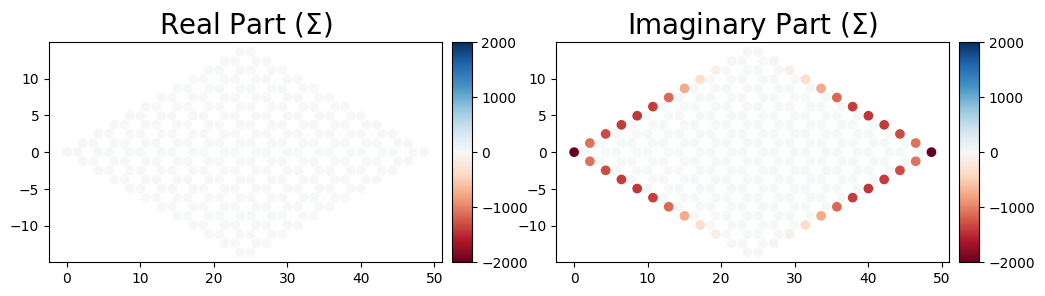

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
rse_diag = np.diagonal(RSE_RE, axis1=1, axis2=2).copy()
H = output["H_re"]
geomNN = H.geometry
x, y = H.geometry.xyz[:, :2].T

# Define the data parts and titles for a clean loop
E0_idx = np.nonzero(energies == 0)
data_parts = [rse_diag[E0_idx].real, rse_diag[E0_idx].imag]
titles = [r"Real Part ($\Sigma$)", r"Imaginary Part ($\Sigma$)"]

imag_min = rse_diag.imag.min()
imag_max = rse_diag.imag.max()

real_min = rse_diag.real.min()
real_max = rse_diag.real.max()

# vmins = [np.min([imag_min, -imag_max]), np.min([real_min, -real_max])]
# vmaxs = [np.max([-imag_min, imag_max]), np.max([-real_min, real_max])]
vmins = [-2e3,]*2
vmaxs = [2e3,]*2

print(imag_max, imag_min)


fig, ax = plt.subplots(1,2, figsize=(12,12))
for i in range(2):
    # Create the scatter plot
    sc = ax[i].scatter(x, y, c=data_parts[i], cmap="RdBu", 
                        vmin=vmins[i], vmax=vmaxs[i])
    
    ax[i].set_title(titles[i], size=20)
    ax[i].axis("scaled")
    
    # --- The Colorbar Logic ---
    # Create a divider for the current axes
    divider = make_axes_locatable(ax[i])
    # Append an axes to the right, 5% width of the main plot
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc, cax=cax)

# plt.tight_layout()
# plt.show()

 

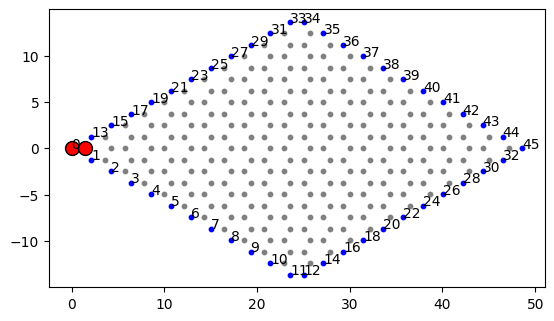

In [8]:
fig, ax = plt.subplots()
HamSE = H.sub(output["electrode_idx"])
for i in np.arange(0, geomNN.na):
    if i < HamSE.na:
        ax.text(geomNN.xyz[i, 0], geomNN.xyz[i, 1], s=i, c="k")
        ax.scatter(geomNN.xyz[i, 0], geomNN.xyz[i, 1], c="b", s=10, label="Elec")
    else:
        ax.scatter(geomNN.xyz[i, 0], geomNN.xyz[i, 1], c="gray", s=10, label="Dev")
for idx in np.arange(0, Ham0.na):
    ax.scatter(Ham0.geometry.xyz[idx,0], Ham0.geometry.xyz[idx, 1], c="red", s=100, edgecolors="k", linewidth=1)
ax.axis('scaled');

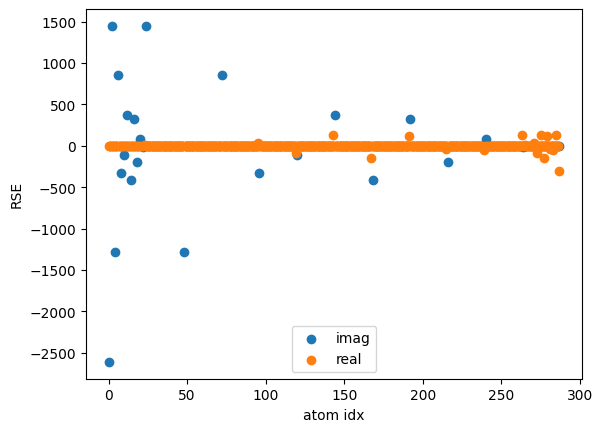

In [9]:
fig, ax = plt.subplots()
ax.scatter(alist, np.imag(RSE_E0).diagonal(), label="imag")
ax.scatter(alist, np.real(RSE_E0).diagonal(), label="real")
ax.set(xlabel="atom idx", ylabel="RSE")
ax.legend(loc="lower center")


[Text(0.5, 0, 'x position'), Text(0, 0.5, 'RSE')]

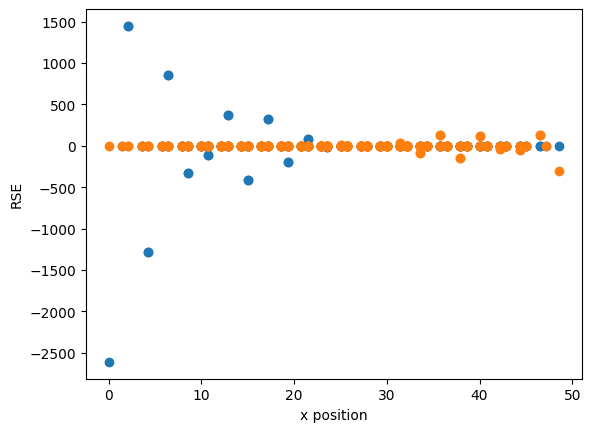

In [10]:
fig, ax = plt.subplots()
ax.scatter(geomNN.xyz[:, 0], np.imag(RSE_E0).diagonal(), label="imag")
ax.scatter(geomNN.xyz[:, 0], np.real(RSE_E0).diagonal(), label="real")
ax.set(xlabel="x position", ylabel="RSE")

# Looping over tiling size

In [11]:
Ns = np.array([4*i+1 for i in range(2, 11)]); print(f"Ns : {Ns}, shape={Ns.shape}")
# nks = np.int16(np.ceil([(3+i)*900/Ns[i] for i in range(0,len(Ns))])); print(f"nks : {nks}, shape={nks.shape}")
nk1 = int(np.ceil(3*900/12))
eta = 1e-3j
energies = np.array([0])
OUTPUTS = {}

diffs = np.empty(shape=(len(Ns),), dtype=complex)
for i, N in enumerate(tqdm(Ns, desc="Looping tiling")):
    n0 = 0 # corner atom
    n_halfway_side = N//2+1
    E0_idx = energies[np.nonzero(energies == 0)]
    Ham0 = systemInit(1.43, -2.7)
    H_final, rse, alist, elist = setup_ham_rse(Ham0, tile=N, nk1=nk1, eta=eta)
    out = calculate_spectral_GF(energies, eta=eta, Ham_sub=H_final, rse=rse, alist=alist, elist=elist)
    
    
    
    OUTPUTS[f"{N}"] = out
    rse_re = out["RSE"]
    rse_diag = np.diagonal(rse_re, axis1=1, axis2=2).copy()
    rse_diff, = rse_diag[E0_idx, n0] - rse_diag[E0_idx, n_halfway_side]
    diffs[i] = rse_diff
OUTPUTS[f"rse_diff"] = diffs

Ns : [ 9 13 17 21 25 29 33 37 41], shape=(9,)


Looping tiling:   0%|          | 0/9 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

...

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

# Tiling - $N$ vs. $|\Sigma_0 - \Sigma_{N/2}|$

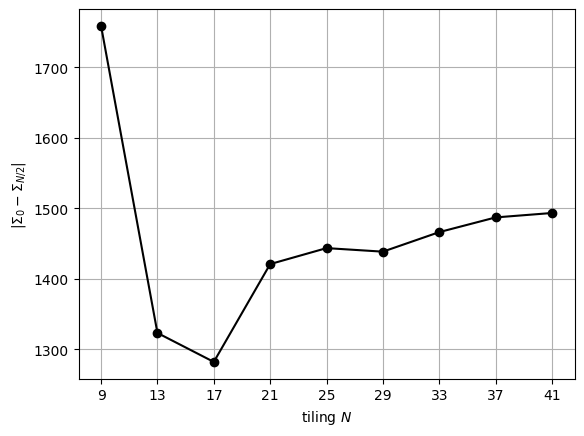

In [25]:
fig, ax = plt.subplots()
imag_diffs = np.imag(OUTPUTS["rse_diff"])
abs_imag_diffs = np.abs(imag_diffs)
ax.plot(Ns, abs_imag_diffs, 'ko-')
ax.set(xlabel="tiling $N$", ylabel=r"$|\Sigma_0 - \Sigma_{N/2}|$", xticks=Ns)
ax.grid()

In [ ]:
from ipywidgets import interact, Dropdown, fixed

N_menu = Dropdown(value=Ns[0], options=Ns)
part_options = ["real", "imag"]
part_menu = Dropdown(value=part_options[1], options=part_options)
@interact(output=fixed(OUTPUTS), N=N_menu, part=part_menu)
def plot_rse(output, N, part="imag"):
    current_out = output[str(N)]
    rse = current_out["RSE"]
    energies = current_out["E"]
    E0_idx = energies[np.nonzero(energies==0)]
    rse_diag = np.diagonal(rse, axis1=1, axis2=2)
    
    if part.lower() == "real":
        rse_diag = np.real(rse_diag)
    elif part.lower() == "imag":
        rse_diag = np.imag(rse_diag)
    else:
        raise ValueError(f"part must be imag or real but was : '{part}'")
    
    H = current_out["H_re"]
    x,y = H.geometry.xyz[:, :2].T
    
    
    
    vmax = rse_diag.max()
    vmin = rse_diag.min()
    vmin = np.min([vmin, -vmax])
    vmax = np.max([-vmin, vmax])
    vmax = 2.5e3
    vmin = -vmax
    
    fig, ax = plt.subplots(figsize=(12,12))
    sc = ax.scatter(x, y, c=rse_diag[E0_idx, :], vmin=vmin, vmax=vmax, cmap="RdBu")
    
    divider = make_axes_locatable(ax)
    
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc, cax)
    ax.axis('scaled')
    
    

interactive(children=(Dropdown(description='N', options=(np.int64(9), np.int64(13), np.int64(17), np.int64(21)…